## Day 11 – Data & Domain


### Use Case
*Focus: domain and application context*

> In the context of **financial risk monitoring**, one-dimensional price signals generated by the Swiss Market Index (SMI) are recorded daily using the SIX Swiss Exchange in order to assess market trends and detect emerging risk patterns.  
> The resulting digital signals are analyzed by **risk management systems** to perform trend estimation, noise reduction, and feature enhancement for portfolio management.  
> This use case is particularly relevant for **Switzerland** because institutional investors managing CHF-denominated assets rely on accurately smoothed price signals to distinguish genuine market trends from short-term noise, and Switzerland's financial industry is a cornerstone of the national economy.

### Problem Statement
*Focus: technical vulnerability*

> This project addresses the problem of applying **convolution-based smoothing and deconvolution-based signal restoration** to the SMI daily closing price signal within the context of financial trend analysis in Switzerland.  
> If the smoothing kernel is chosen too narrow, high-frequency noise components remain in the signal, obscuring genuine trend patterns and leading to false trend reversal signals. If the kernel is chosen too wide, important transient features such as sudden drawdowns, earnings reactions, or regime changes are attenuated and blurred, delaying risk detection.  
> Preserving the **temporal sharpness of trend transitions while reducing short-term noise** is essential for reliable risk monitoring in this financial use case.

**Role of deconvolution:** After smoothing, deconvolution becomes relevant as a means of restoring attenuated features or approximating the original signal structure. If a known smoothing operation has been applied, deconvolution can potentially recover sharp transitions and peak amplitudes that were blurred during filtering. However, deconvolution is an inherently ill-posed inverse problem, particularly sensitive to noise amplification, and its practical feasibility must be assessed explicitly.

### Experimental Objective
*Focus: investigation goal at the conceptual level*

> The objective of this project is to investigate how convolution-based smoothing affects the representation of trend structures and transient features in the SMI daily price signal, and to assess under which conditions deconvolution can meaningfully restore relevant signal characteristics after filtering. The goal is to understand the trade-off between noise reduction and feature preservation in the context of financial risk monitoring.

### Data Definition, Source, and Visualization
*Focus: data characteristics, data source, and visual inspection*

> The selected signal represents **daily closing prices of the Swiss Market Index (SMI)** over one trading year, generated by market-aggregated trade executions on the SIX Swiss Exchange, measured using the electronic order book, and expressed in **CHF**.  
> Its relevant characteristics include a **superposition of long-term trends, medium-term oscillations, and short-term noise-like fluctuations**, which are important for testing the smoothing/restoration trade-off.  
> The data originate from the **Yahoo Finance API** (ticker: ^SSMI), provided by Yahoo/ICE Data Services, and are appropriate because they offer publicly available, well-documented daily price data with sufficient length and variability for convolution analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.signal import wiener

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [2]:
smi_daily = yf.download("^SSMI", period="1y", interval="1d", progress=False)
if isinstance(smi_daily.columns, pd.MultiIndex):
    smi_daily.columns = smi_daily.columns.get_level_values(0)

price = smi_daily['Close'].dropna().values.astype(float)
time_index = smi_daily['Close'].dropna().index
N = len(price)

print(f"Data points: {N} trading days")
print(f"Time span: {time_index[0].strftime('%Y-%m-%d')} to {time_index[-1].strftime('%Y-%m-%d')}")

/var/folders/qr/40kwqhb578jfzhtt2nw831h40000gn/T/ipykernel_9347/2745288949.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  smi_daily = yf.download("^SSMI", period="1y", interval="1d", progress=False)


Data points: 249 trading days
Time span: 2025-03-24 to 2026-03-23


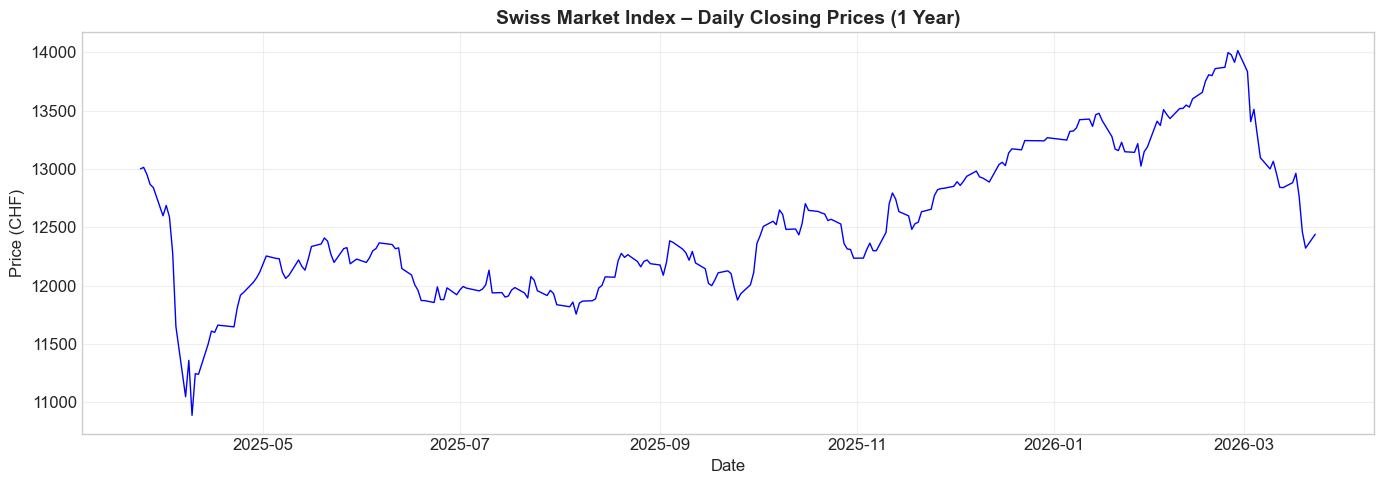

In [3]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time_index, price, 'b-', linewidth=1)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (CHF)', fontsize=12)
ax.set_title('Swiss Market Index – Daily Closing Prices (1 Year)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observations:**
> The visualization illustrates the SMI daily closing price signal over one trading year, with notable superposition of a long-term trend component and shorter-term fluctuations that represent both genuine market dynamics and noise-like day-to-day variations. This signal segment was selected because it contains both smooth trend periods and sharp transitions (drawdowns, recoveries), making it ideal for testing the convolution/deconvolution trade-off relevant to the defined use case.